In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
df = pd.read_csv('WineQT.csv')

print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

In [70]:
print("Quantidade de linhas:", len(df))
print("Shape:", df.shape)
print("IDs únicos:", df['Id'].nunique())

Quantidade de linhas: 1143
Shape: (1143, 13)
IDs únicos: 1143


In [71]:
df = df.drop('Id', axis=1)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [73]:
print(df['quality'].value_counts().sort_index())
#contagem de valores por nº da qualidade

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


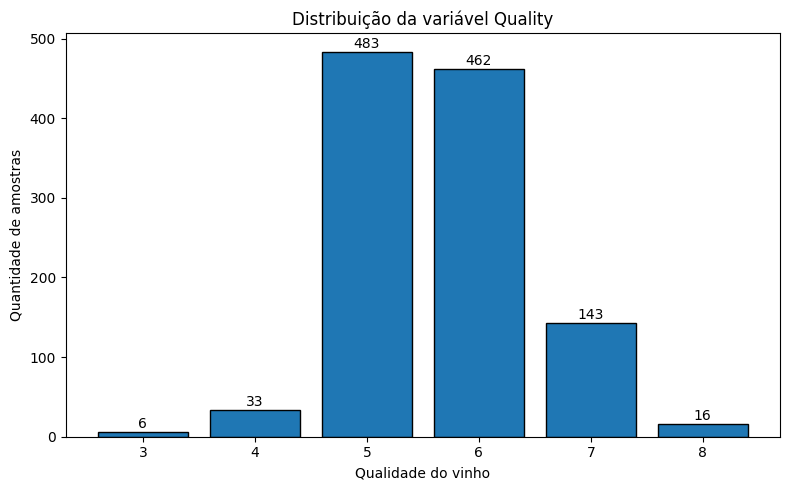

In [74]:
# Contagem das classes
quality_counts = df['quality'].value_counts().sort_index()

# Gráfico
plt.figure(figsize=(8,5))
plt.bar(quality_counts.index.astype(str),
        quality_counts.values,
        edgecolor='black')

plt.title('Distribuição da variável Quality')
plt.xlabel('Qualidade do vinho')
plt.ylabel('Quantidade de amostras')

# Exibe os valores acima das barras
for i, v in enumerate(quality_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [75]:
df['quality_bin'] = df['quality'].apply(
    lambda x: 1 if x >= 7 else 0
)
#classifica com 0 e 1 as notas de qualidade

In [76]:
df['quality_bin'] = df['quality'].apply(
    lambda x: 1 if x >= 7 else 0
)

print(df['quality_bin'].value_counts())
# 0 - baixa/média qualidade
# 1 - alta qualidae

quality_bin
0    984
1    159
Name: count, dtype: int64


In [77]:
df['quality_bin'].value_counts(normalize=True)
#Percentual antes de fazer o balanceamento de classes

,proportion
quality_bin,
0,0.860892
1,0.139108


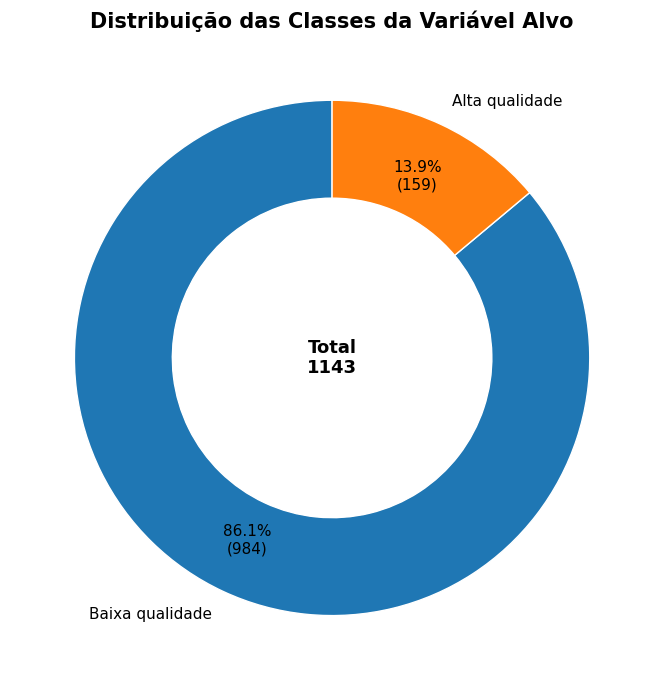

In [78]:
quality_bin_counts = df['quality_bin'].value_counts().sort_index()

labels = ['Baixa qualidade', 'Alta qualidade']

fig, ax = plt.subplots(figsize=(7,7))

wedges, texts, autotexts = ax.pie(
    quality_bin_counts,
    labels=labels,
    autopct=lambda p: f'{p:.1f}%\n({int(round(p/100*quality_bin_counts.sum()))})',
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(width=0.38, edgecolor='white'),
    textprops=dict(color='black', fontsize=11)
)

# Círculo central para formar a rosca
centre_circle = plt.Circle((0, 0), 0.62, fc='white')
fig.gca().add_artist(centre_circle)

# Total de amostras no centro
plt.text(
    0, 0,
    f'Total\n{quality_bin_counts.sum()}',
    ha='center',
    va='center',
    fontsize=13,
    fontweight='bold'
)

plt.title(
    'Distribuição das Classes da Variável Alvo',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [79]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_bin
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,0.139108
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,0.346210
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,0.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,0.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,0.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1.000000


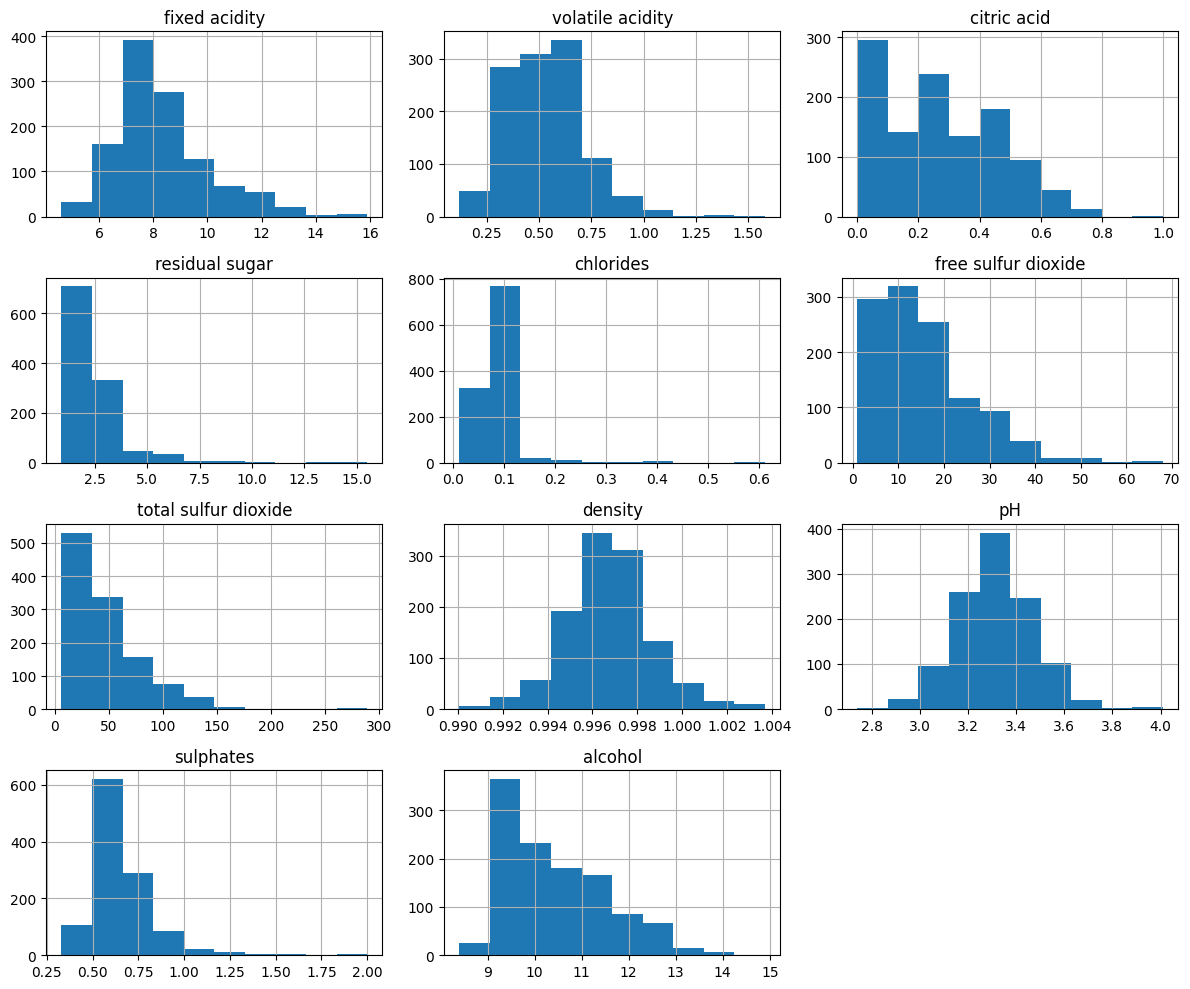

In [80]:
df.drop(columns=['quality', 'quality_bin']).hist(figsize=(12,10))

plt.tight_layout()
plt.show()

In [81]:
corr_quality = df.corr(numeric_only=True)['quality'].sort_values(ascending=False)
print(corr_quality)
#Correlação com a qualidade
#A correlação mede a intensidade e a direção da relação linear entre duas variáveis. O coeficiente de correlação de Pearson varia de -1 a +1:

quality                 1.000000
quality_bin             0.720433
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64


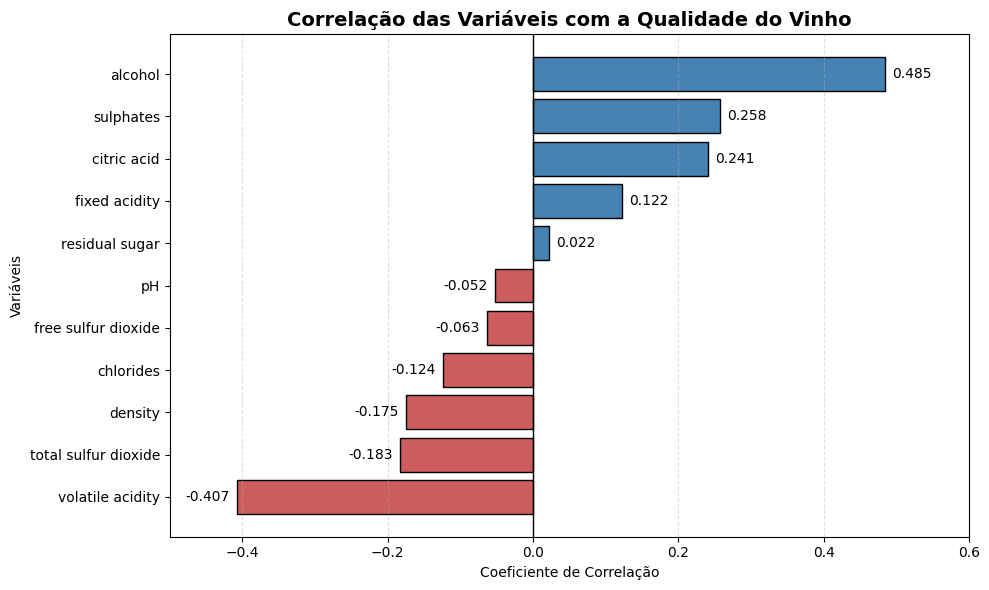

In [82]:
# Correlação com a variável quality
corr_quality = (
    df.corr(numeric_only=True)['quality']
      .drop(['quality', 'quality_bin'])   # Remove as duas variáveis
      .sort_values()
)

# Cores: azul para positivo e vermelho para negativo
cores = ['steelblue' if x > 0 else 'indianred' for x in corr_quality]

plt.figure(figsize=(10,6))

bars = plt.barh(
    corr_quality.index,
    corr_quality.values,
    color=cores,
    edgecolor='black'
)

# Linha vertical em x = 0
plt.axvline(0, color='black', linewidth=1)

# Adiciona os valores nas barras
for bar in bars:
    largura = bar.get_width()

    if largura >= 0:
        plt.text(
            largura + 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{largura:.3f}',
            va='center',
            ha='left',
            fontsize=10
        )
    else:
        plt.text(
            largura - 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{largura:.3f}',
            va='center',
            ha='right',
            fontsize=10
        )

plt.title('Correlação das Variáveis com a Qualidade do Vinho',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Coeficiente de Correlação')
plt.ylabel('Variáveis')

plt.xlim(-0.5, 0.6)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

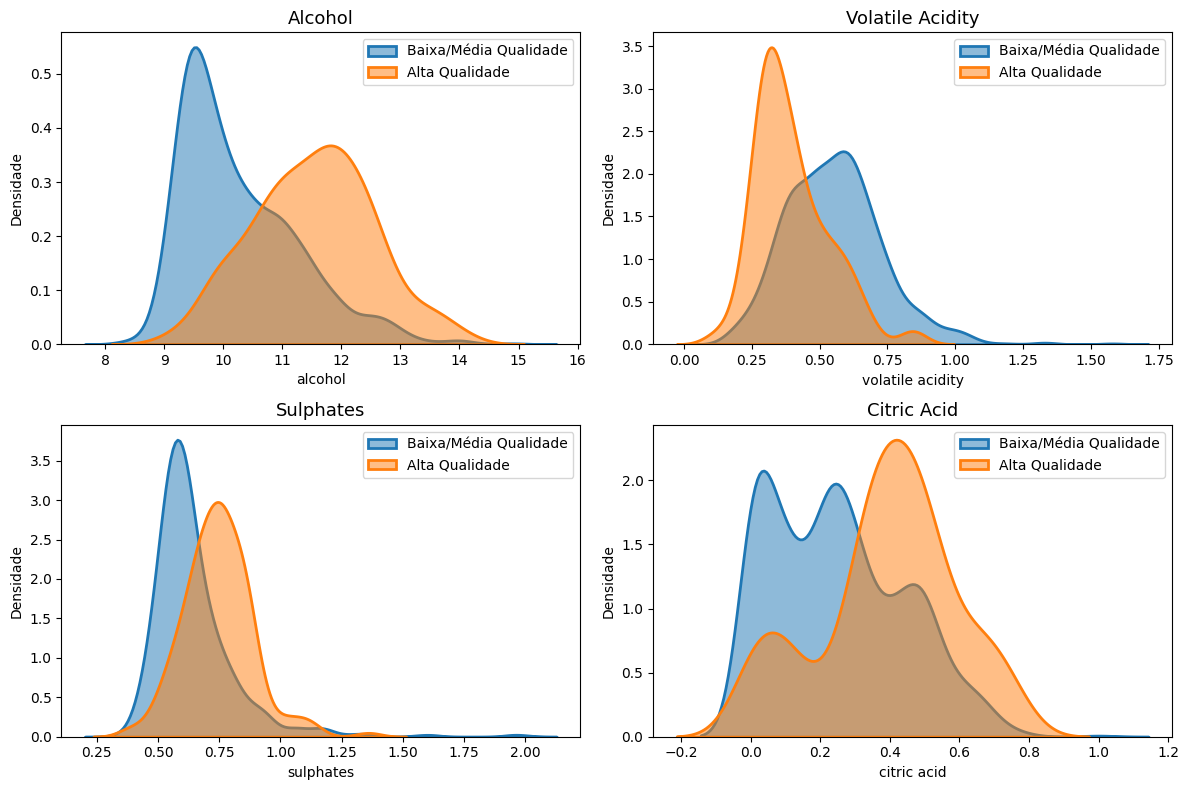

In [83]:
# Variáveis mais correlacionadas
variaveis = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, var in enumerate(variaveis):

    sns.kdeplot(
        data=df[df['quality_bin'] == 0],
        x=var,
        fill=True,
        alpha=0.5,
        linewidth=2,
        label='Baixa/Média Qualidade',
        ax=axes[i]
    )

    sns.kdeplot(
        data=df[df['quality_bin'] == 1],
        x=var,
        fill=True,
        alpha=0.5,
        linewidth=2,
        label='Alta Qualidade',
        ax=axes[i]
    )

    axes[i].set_title(var.title(), fontsize=13)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Densidade")
    axes[i].legend()

plt.tight_layout()
plt.show()

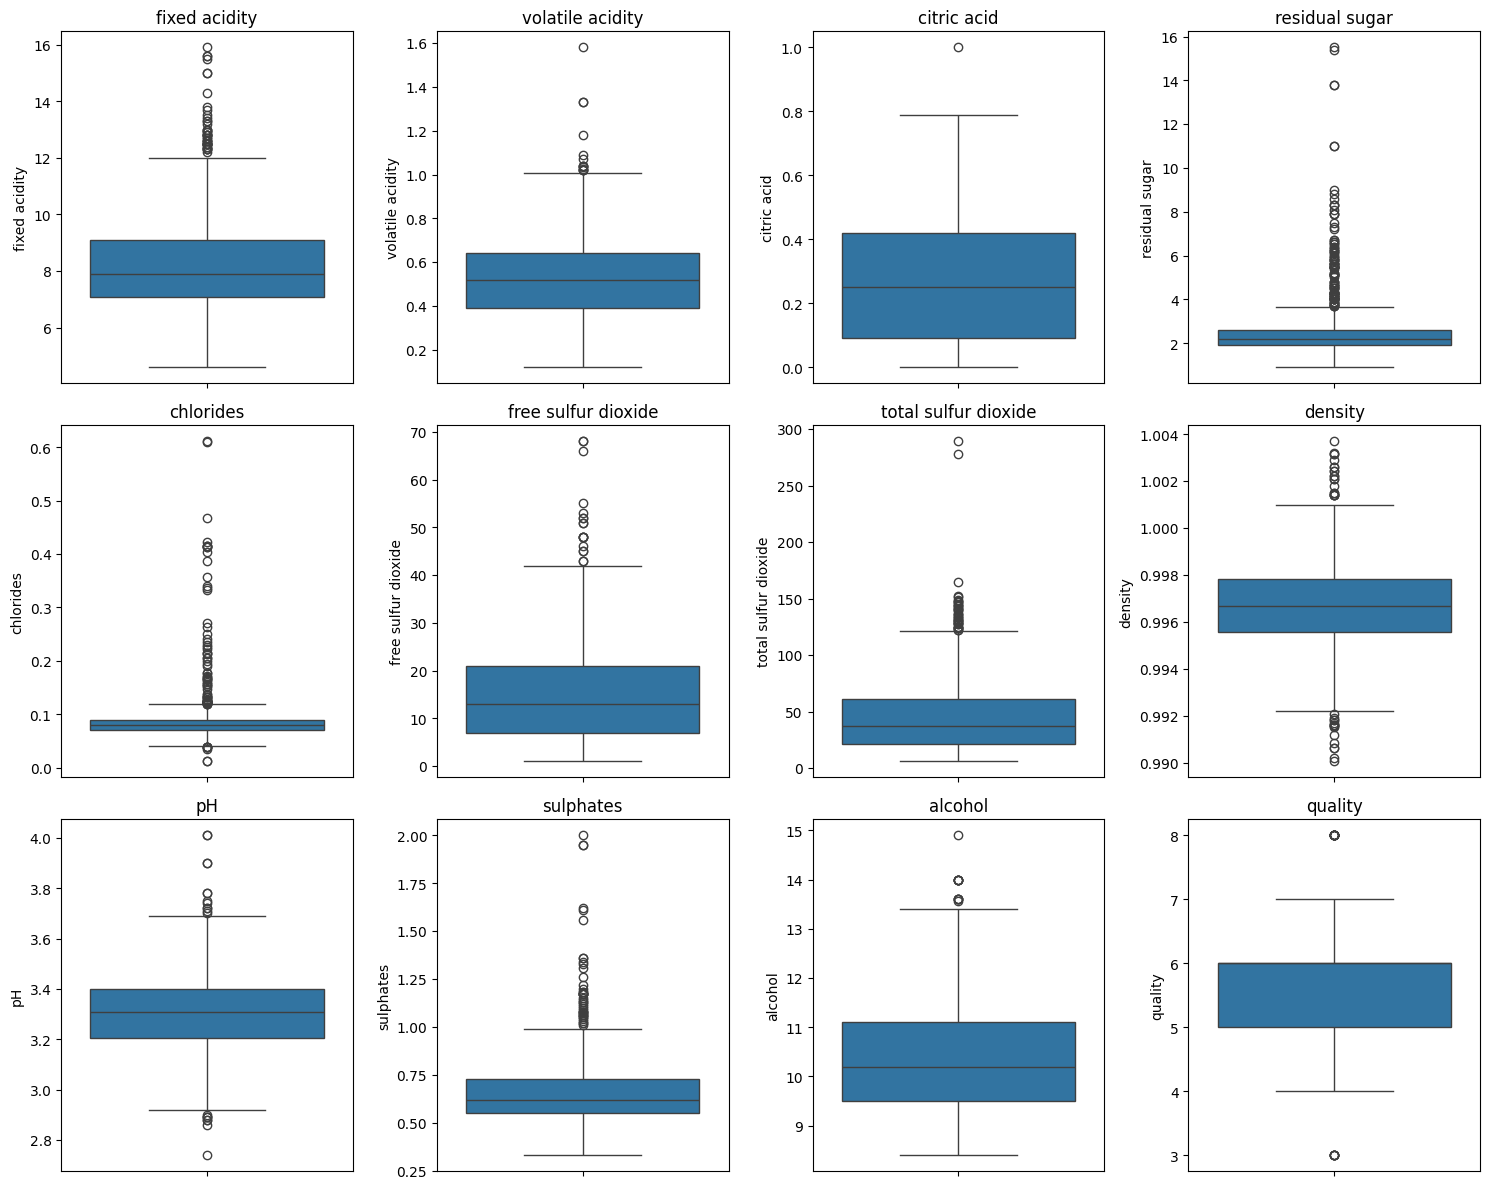

In [84]:
variaveis = df.drop(columns=['quality_bin']).columns

plt.figure(figsize=(15,12))

for i, col in enumerate(variaveis):
    plt.subplot(3,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [85]:
features_all = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

In [86]:
features_top4 = [
    'alcohol',
    'volatile acidity',
    'sulphates',
    'citric acid'
]

In [87]:
features_top7 = [
    'alcohol',
    'volatile acidity',
    'sulphates',
    'citric acid',
    'total sulfur dioxide',
    'density',
    'chlorides'
]

In [88]:
features_alcohol = ['alcohol']

In [89]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

def preparar_dados(df, features):

    # 1. Separação X e y
    X = df[features]
    y = df["quality_bin"]

    # 2. Train / Test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    # 3. SMOTE (apenas treino)
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

    # 4. Padronização
    scaler = StandardScaler()
    X_train_bal_scaled = scaler.fit_transform(X_train_bal)
    X_test_scaled = scaler.transform(X_test)

    # 5. Retorno completo
    return (
    X_train,
    y_train,
    X_train_bal,
    X_train_bal_scaled,
    X_test_scaled,
    y_train_bal,
    y_test
)


In [90]:
# Modelo 1
X_train_all, y_train_all, X_train_bal_all, X_train_bal_scaled_all, X_test_scaled_all, y_train_bal_all, y_test_all = preparar_dados(df, features_all)

# Modelo 2
X_train_top4, y_train_top4, X_train_bal_top4, X_train_bal_scaled_top4, X_test_scaled_top4, y_train_bal_top4, y_test_top4 = preparar_dados(df, features_top4)

# Modelo 3
X_train_top7, y_train_top7, X_train_bal_top7, X_train_bal_scaled_top7, X_test_scaled_top7, y_train_bal_top7, y_test_top7 = preparar_dados(df, features_top7)

# Modelo 4
X_train_alcohol, y_train_alcohol, X_train_bal_alcohol, X_train_bal_scaled_alcohol, X_test_scaled_alcohol, y_train_bal_alcohol, y_test_alcohol = preparar_dados(df, features_alcohol)

In [91]:
print("=== Antes do SMOTE ===")
print(y_train_all.value_counts())

print("\n=== Depois do SMOTE ===")
print(y_train_bal_all.value_counts())

=== Antes do SMOTE ===
quality_bin
0    689
1    111
Name: count, dtype: int64

=== Depois do SMOTE ===
quality_bin
0    689
1    689
Name: count, dtype: int64


In [92]:
import pandas as pd

# Antes da padronização
antes = pd.DataFrame(
    X_train_bal_all,
    columns=features_all
)

# Depois da padronização
depois = pd.DataFrame(
    X_train_bal_scaled_all,
    columns=features_all
)

comparacao = pd.DataFrame({
    "Média Antes": antes.mean(),
    "Média Depois": depois.mean(),
    "Desvio Antes": antes.std(),
    "Desvio Depois": depois.std()
})

comparacao.round(3)

,Média Antes,Média Depois,Desvio Antes,Desvio Depois
fixed acidity,8.638,0.0,1.830,1.0
volatile acidity,0.465,-0.0,0.169,1.0
citric acid,0.338,0.0,0.194,1.0
residual sugar,2.593,-0.0,1.264,1.0
chlorides,0.082,-0.0,0.039,1.0
free sulfur dioxide,14.322,0.0,9.285,1.0
total sulfur dioxide,41.141,0.0,33.137,1.0
density,0.996,0.0,0.002,1.0
pH,3.290,-0.0,0.147,1.0
sulphates,0.699,0.0,0.160,1.0


In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [94]:
# Modelo de Regressão Logística
log_reg_all = LogisticRegression(random_state=42, max_iter=1000)
log_reg_all.fit(X_train_bal_scaled_all, y_train_bal_all)

LogisticRegression(max_iter=1000, random_state=42)

In [95]:
# Predições
y_pred_log_all = log_reg_all.predict(X_test_scaled_all)

In [96]:
# Métricas
print("Accuracy :", accuracy_score(y_test_all, y_pred_log_all))
print("Precision:", precision_score(y_test_all, y_pred_log_all))
print("Recall   :", recall_score(y_test_all, y_pred_log_all))
print("F1-score :", f1_score(y_test_all, y_pred_log_all))

Accuracy : 0.7755102040816326
Precision: 0.34065934065934067
Recall   : 0.6458333333333334
F1-score : 0.4460431654676259


In [97]:
cm_LogReg_all = confusion_matrix(
    y_test_all,
    y_pred_log_all
)

print(cm_LogReg_all)

[[235  60]
 [ 17  31]]


In [98]:
print(
    classification_report(
        y_test_all,
        y_pred_log_all
    )
)

              precision    recall  f1-score   support

           0       0.93      0.80      0.86       295
           1       0.34      0.65      0.45        48

    accuracy                           0.78       343
   macro avg       0.64      0.72      0.65       343
weighted avg       0.85      0.78      0.80       343



In [99]:
log_reg_top4 = LogisticRegression(random_state=42, max_iter=1000)
log_reg_top4.fit(X_train_bal_scaled_top4, y_train_bal_top4)

y_pred_log_top4 = log_reg_top4.predict(X_test_scaled_top4)
# Modelo 2 - treinando top4

In [100]:
print("=== LogReg - Modelo 2 - (Top 4) ===")
print(f"Accuracy : {accuracy_score(y_test_top4, y_pred_log_top4):.4f}")
print(f"Precision: {precision_score(y_test_top4, y_pred_log_top4):.4f}")
print(f"Recall   : {recall_score(y_test_top4, y_pred_log_top4):.4f}")
print(f"F1-score : {f1_score(y_test_top4, y_pred_log_top4):.4f}")

print ("\nMatriz de Confusão")
print(confusion_matrix(y_test_top4, y_pred_log_top4))

print ("\nRelatório de Classificação")
print(classification_report(y_test_top4, y_pred_log_top4))


=== LogReg - Modelo 2 - (Top 4) ===
Accuracy : 0.7609
Precision: 0.3191
Recall   : 0.6250
F1-score : 0.4225

Matriz de Confusão
[[231  64]
 [ 18  30]]

Relatório de Classificação
              precision    recall  f1-score   support

           0       0.93      0.78      0.85       295
           1       0.32      0.62      0.42        48

    accuracy                           0.76       343
   macro avg       0.62      0.70      0.64       343
weighted avg       0.84      0.76      0.79       343



In [101]:
log_reg_top7 = LogisticRegression(random_state=42, max_iter=1000)
log_reg_top7.fit(X_train_bal_scaled_top7, y_train_bal_top7)

y_pred_log_top7 = log_reg_top7.predict(X_test_scaled_top7)
# Modelo 3 - treinando top7

In [102]:
print("=== LogReg - Modelo 3 - (Top 7) ===")
print(f"Accuracy : {accuracy_score(y_test_top7, y_pred_log_top7):.4f}")
print(f"Precision: {precision_score(y_test_top7, y_pred_log_top7):.4f}")
print(f"Recall   : {recall_score(y_test_top7, y_pred_log_top7):.4f}")
print(f"F1-score : {f1_score(y_test_top7, y_pred_log_top7):.4f}")

print ("\nMatriz de Confusão")
print(confusion_matrix(y_test_top7, y_pred_log_top7))

print ("\nRelatório de Classificação")
print(classification_report(y_test_top7, y_pred_log_top7))

=== LogReg - Modelo 3 - (Top 7) ===
Accuracy : 0.7638
Precision: 0.3263
Recall   : 0.6458
F1-score : 0.4336

Matriz de Confusão
[[231  64]
 [ 17  31]]

Relatório de Classificação
              precision    recall  f1-score   support

           0       0.93      0.78      0.85       295
           1       0.33      0.65      0.43        48

    accuracy                           0.76       343
   macro avg       0.63      0.71      0.64       343
weighted avg       0.85      0.76      0.79       343



In [103]:
log_reg_alcohol = LogisticRegression(random_state=42, max_iter=1000)
log_reg_alcohol.fit(X_train_bal_scaled_alcohol, y_train_bal_alcohol)

y_pred_log_alcohol = log_reg_alcohol.predict(X_test_scaled_alcohol)
#Modelo 4 - Alcohol

In [104]:
print("=== LogReg - Modelo 4 - (Alcohol) ===")
print(f"Accuracy : {accuracy_score(y_test_alcohol, y_pred_log_alcohol):.4f}")
print(f"Precision: {precision_score(y_test_alcohol, y_pred_log_alcohol):.4f}")
print(f"Recall   : {recall_score(y_test_alcohol, y_pred_log_alcohol):.4f}")
print(f"F1-score : {f1_score(y_test_alcohol, y_pred_log_alcohol):.4f}")

print ("\nMatriz de Confusão")
print(confusion_matrix(y_test_alcohol, y_pred_log_alcohol))

print ("\nRelatório de Classificação")
print(classification_report(y_test_alcohol, y_pred_log_alcohol))

=== LogReg - Modelo 4 - (Alcohol) ===
Accuracy : 0.7055
Precision: 0.2810
Recall   : 0.7083
F1-score : 0.4024

Matriz de Confusão
[[208  87]
 [ 14  34]]

Relatório de Classificação
              precision    recall  f1-score   support

           0       0.94      0.71      0.80       295
           1       0.28      0.71      0.40        48

    accuracy                           0.71       343
   macro avg       0.61      0.71      0.60       343
weighted avg       0.85      0.71      0.75       343



In [105]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [106]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

In [107]:
knn.fit(
    X_train_bal_scaled_all,
    y_train_bal_all
)

KNeighborsClassifier()

In [108]:
y_pred_knn_all = knn.predict(
    X_test_scaled_all
)

In [109]:
print("Accuracy :", accuracy_score(y_test_all, y_pred_knn_all))
print("Precision:", precision_score(y_test_all, y_pred_knn_all))
print("Recall   :", recall_score(y_test_all, y_pred_knn_all))
print("F1-score :", f1_score(y_test_all, y_pred_knn_all))

Accuracy : 0.7784256559766763
Precision: 0.34782608695652173
Recall   : 0.6666666666666666
F1-score : 0.45714285714285713


In [110]:
cm_knn_all = confusion_matrix(
    y_test_all,
    y_pred_knn_all
)

print(cm_knn_all)

[[235  60]
 [ 16  32]]


In [111]:
print(
    classification_report(
        y_test_all,
        y_pred_knn_all
    )
)

              precision    recall  f1-score   support

           0       0.94      0.80      0.86       295
           1       0.35      0.67      0.46        48

    accuracy                           0.78       343
   macro avg       0.64      0.73      0.66       343
weighted avg       0.85      0.78      0.80       343



In [112]:
knn.fit(
    X_train_bal_scaled_top4,
    y_train_bal_top4
)

y_pred_knn_top4 = knn.predict(
    X_test_scaled_top4
)
#Modelo 2 - treinando

In [113]:
print("=== KNN - Modelo 2 (Top 4) ===")

print(f"Accuracy : {accuracy_score(y_test_top4, y_pred_knn_top4):.4f}")
print(f"Precision: {precision_score(y_test_top4, y_pred_knn_top4):.4f}")
print(f"Recall   : {recall_score(y_test_top4, y_pred_knn_top4):.4f}")
print(f"F1-score : {f1_score(y_test_top4, y_pred_knn_top4):.4f}")

print("\nMatriz de Confusão")
print(confusion_matrix(y_test_top4, y_pred_knn_top4))

print("\nRelatório de Classificação")
print(classification_report(y_test_top4, y_pred_knn_top4))

=== KNN - Modelo 2 (Top 4) ===
Accuracy : 0.7784
Precision: 0.3478
Recall   : 0.6667
F1-score : 0.4571

Matriz de Confusão
[[235  60]
 [ 16  32]]

Relatório de Classificação
              precision    recall  f1-score   support

           0       0.94      0.80      0.86       295
           1       0.35      0.67      0.46        48

    accuracy                           0.78       343
   macro avg       0.64      0.73      0.66       343
weighted avg       0.85      0.78      0.80       343



In [114]:
knn.fit(
    X_train_bal_scaled_top7,
    y_train_bal_top7
)

y_pred_knn_top7 = knn.predict(
    X_test_scaled_top7
)
#modelo 3 - treinando

In [115]:
print("=== KNN - Modelo 3 (Top 7) ===")

print(f"Accuracy : {accuracy_score(y_test_top7, y_pred_knn_top7):.4f}")
print(f"Precision: {precision_score(y_test_top7, y_pred_knn_top7):.4f}")
print(f"Recall   : {recall_score(y_test_top7, y_pred_knn_top7):.4f}")
print(f"F1-score : {f1_score(y_test_top7, y_pred_knn_top7):.4f}")

print("\nMatriz de Confusão")
print(confusion_matrix(y_test_top7, y_pred_knn_top7))

print("\nRelatório de Classificação")
print(classification_report(y_test_top7, y_pred_knn_top7))

=== KNN - Modelo 3 (Top 7) ===
Accuracy : 0.7638
Precision: 0.3333
Recall   : 0.6875
F1-score : 0.4490

Matriz de Confusão
[[229  66]
 [ 15  33]]

Relatório de Classificação
              precision    recall  f1-score   support

           0       0.94      0.78      0.85       295
           1       0.33      0.69      0.45        48

    accuracy                           0.76       343
   macro avg       0.64      0.73      0.65       343
weighted avg       0.85      0.76      0.79       343



In [116]:
knn.fit(
    X_train_bal_scaled_alcohol,
    y_train_bal_alcohol
)

y_pred_knn_alcohol = knn.predict(
    X_test_scaled_alcohol
)

In [117]:
print("=== KNN - Modelo 4 (Alcohol) ===")

print(f"Accuracy : {accuracy_score(y_test_alcohol, y_pred_knn_alcohol):.4f}")
print(f"Precision: {precision_score(y_test_alcohol, y_pred_knn_alcohol):.4f}")
print(f"Recall   : {recall_score(y_test_alcohol, y_pred_knn_alcohol):.4f}")
print(f"F1-score : {f1_score(y_test_alcohol, y_pred_knn_alcohol):.4f}")

print("\nMatriz de Confusão")
print(confusion_matrix(y_test_alcohol, y_pred_knn_alcohol))

print("\nRelatório de Classificação")
print(classification_report(y_test_alcohol, y_pred_knn_alcohol))

=== KNN - Modelo 4 (Alcohol) ===
Accuracy : 0.8163
Precision: 0.3585
Recall   : 0.3958
F1-score : 0.3762

Matriz de Confusão
[[261  34]
 [ 29  19]]

Relatório de Classificação
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       295
           1       0.36      0.40      0.38        48

    accuracy                           0.82       343
   macro avg       0.63      0.64      0.63       343
weighted avg       0.82      0.82      0.82       343



In [118]:
from sklearn.ensemble import RandomForestClassifier

In [119]:
rf_all = RandomForestClassifier(random_state=42)
rf_top4 = RandomForestClassifier(random_state=42)
rf_top7 = RandomForestClassifier(random_state=42)
rf_alcohol = RandomForestClassifier(random_state=42)

In [120]:
rf_all.fit(X_train_bal_scaled_all, y_train_bal_all)

rf_top4.fit(X_train_bal_scaled_top4, y_train_bal_top4)

rf_top7.fit(X_train_bal_scaled_top7, y_train_bal_top7)

rf_alcohol.fit(X_train_bal_scaled_alcohol, y_train_bal_alcohol)

RandomForestClassifier(random_state=42)

In [121]:
y_pred_rf_all = rf_all.predict(X_test_scaled_all)
y_pred_rf_top4 = rf_top4.predict(X_test_scaled_top4)
y_pred_rf_top7 = rf_top7.predict(X_test_scaled_top7)
y_pred_rf_alcohol = rf_alcohol.predict(X_test_scaled_alcohol)

In [122]:
resultados = []

In [123]:
resultados.append({
    "Modelo": "KNN",
    "Grupo": "Todas",
    "Accuracy": accuracy_score(y_test_all, y_pred_knn_all),
    "Precision": precision_score(y_test_all, y_pred_knn_all),
    "Recall": recall_score(y_test_all, y_pred_knn_all),
    "F1-score": f1_score(y_test_all, y_pred_knn_all)
})

resultados.append({
    "Modelo": "KNN",
    "Grupo": "Top 4",
    "Accuracy": accuracy_score(y_test_top4, y_pred_knn_top4),
    "Precision": precision_score(y_test_top4, y_pred_knn_top4),
    "Recall": recall_score(y_test_top4, y_pred_knn_top4),
    "F1-score": f1_score(y_test_top4, y_pred_knn_top4)
})

resultados.append({
    "Modelo": "KNN",
    "Grupo": "Top 7",
    "Accuracy": accuracy_score(y_test_top7, y_pred_knn_top7),
    "Precision": precision_score(y_test_top7, y_pred_knn_top7),
    "Recall": recall_score(y_test_top7, y_pred_knn_top7),
    "F1-score": f1_score(y_test_top7, y_pred_knn_top7)
})

resultados.append({
    "Modelo": "KNN",
    "Grupo": "Alcohol",
    "Accuracy": accuracy_score(y_test_alcohol, y_pred_knn_alcohol),
    "Precision": precision_score(y_test_alcohol, y_pred_knn_alcohol),
    "Recall": recall_score(y_test_alcohol, y_pred_knn_alcohol),
    "F1-score": f1_score(y_test_alcohol, y_pred_knn_alcohol)
})

In [124]:
resultados.append({
    "Modelo": "Random Forest",
    "Grupo": "Todas",
    "Accuracy": accuracy_score(y_test_all, y_pred_rf_all),
    "Precision": precision_score(y_test_all, y_pred_rf_all),
    "Recall": recall_score(y_test_all, y_pred_rf_all),
    "F1-score": f1_score(y_test_all, y_pred_rf_all)
})

resultados.append({
    "Modelo": "Random Forest",
    "Grupo": "Top 4",
    "Accuracy": accuracy_score(y_test_top4, y_pred_rf_top4),
    "Precision": precision_score(y_test_top4, y_pred_rf_top4),
    "Recall": recall_score(y_test_top4, y_pred_rf_top4),
    "F1-score": f1_score(y_test_top4, y_pred_rf_top4)
})

resultados.append({
    "Modelo": "Random Forest",
    "Grupo": "Top 7",
    "Accuracy": accuracy_score(y_test_top7, y_pred_rf_top7),
    "Precision": precision_score(y_test_top7, y_pred_rf_top7),
    "Recall": recall_score(y_test_top7, y_pred_rf_top7),
    "F1-score": f1_score(y_test_top7, y_pred_rf_top7)
})

resultados.append({
    "Modelo": "Random Forest",
    "Grupo": "Alcohol",
    "Accuracy": accuracy_score(y_test_alcohol, y_pred_rf_alcohol),
    "Precision": precision_score(y_test_alcohol, y_pred_rf_alcohol),
    "Recall": recall_score(y_test_alcohol, y_pred_rf_alcohol),
    "F1-score": f1_score(y_test_alcohol, y_pred_rf_alcohol)
})

In [125]:
# Regressão Logística - Todas
resultados.append({
    "Modelo": "Logistic Regression",
    "Grupo": "Todas",
    "Accuracy": accuracy_score(y_test_all, y_pred_log_all),
    "Precision": precision_score(y_test_all, y_pred_log_all),
    "Recall": recall_score(y_test_all, y_pred_log_all),
    "F1-score": f1_score(y_test_all, y_pred_log_all)
})

# Regressão Logística - Top 4
resultados.append({
    "Modelo": "Logistic Regression",
    "Grupo": "Top 4",
    "Accuracy": accuracy_score(y_test_top4, y_pred_log_top4),
    "Precision": precision_score(y_test_top4, y_pred_log_top4),
    "Recall": recall_score(y_test_top4, y_pred_log_top4),
    "F1-score": f1_score(y_test_top4, y_pred_log_top4)
})

# Regressão Logística - Top 7
resultados.append({
    "Modelo": "Logistic Regression",
    "Grupo": "Top 7",
    "Accuracy": accuracy_score(y_test_top7, y_pred_log_top7),
    "Precision": precision_score(y_test_top7, y_pred_log_top7),
    "Recall": recall_score(y_test_top7, y_pred_log_top7),
    "F1-score": f1_score(y_test_top7, y_pred_log_top7)
})

# Regressão Logística - Alcohol
resultados.append({
    "Modelo": "Logistic Regression",
    "Grupo": "Alcohol",
    "Accuracy": accuracy_score(y_test_alcohol, y_pred_log_alcohol),
    "Precision": precision_score(y_test_alcohol, y_pred_log_alcohol),
    "Recall": recall_score(y_test_alcohol, y_pred_log_alcohol),
    "F1-score": f1_score(y_test_alcohol, y_pred_log_alcohol)
})

In [126]:
tabela_resultados = pd.DataFrame(resultados)

In [127]:
# Reorganizar a tabela pivotando
tabela_comparativa = tabela_resultados.pivot(
    index="Grupo",
    columns="Modelo",
    values=["Accuracy", "Precision", "Recall", "F1-score"]
)

# Ajustar a ordem das colunas e arredondar
tabela_comparativa = tabela_comparativa.round(4)

tabela_comparativa

Accuracy                                   Precision  \
Modelo       KNN Logistic Regression Random Forest       KNN   
Grupo                                                          
Alcohol   0.8163              0.7055        0.7464    0.3585   
Todas     0.7784              0.7755        0.8397    0.3478   
Top 4     0.7784              0.7609        0.8455    0.3478   
Top 7     0.7638              0.7638        0.8367    0.3333   

                                           Recall                      \
Modelo  Logistic Regression Random Forest     KNN Logistic Regression   
Grupo                                                                   
Alcohol              0.2810        0.3274  0.3958              0.7083   
Todas                0.3407        0.4386  0.6667              0.6458   
Top 4                0.3191        0.4590  0.6667              0.6250   
Top 7                0.3263        0.4310  0.6875              0.6458   

                      F1-score                                    
Modelo  Random Forest      KNN Logistic Regression Random Forest  
Grupo                                                             
Alcohol        0.7708   0.3762              0.4024        0.4596  
Todas          0.5208   0.4571              0.4460        0.4762  
Top 4          0.5833   0.4571              0.4225        0.5138  
Top 7          0.5208   0.4490              0.4336        0.4717

In [128]:
knn_all = KNeighborsClassifier(n_neighbors=5)
knn_top4 = KNeighborsClassifier(n_neighbors=5)
knn_top7 = KNeighborsClassifier(n_neighbors=5)
knn_alcohol = KNeighborsClassifier(n_neighbors=5)

In [129]:
knn_all.fit(X_train_bal_scaled_all, y_train_bal_all)
knn_top4.fit(X_train_bal_scaled_top4, y_train_bal_top4)
knn_top7.fit(X_train_bal_scaled_top7, y_train_bal_top7)
knn_alcohol.fit(X_train_bal_scaled_alcohol, y_train_bal_alcohol)

KNeighborsClassifier()

In [131]:
# Probabilidades KNN
y_prob_knn_all = knn_all.predict_proba(X_test_scaled_all)[:,1]
y_prob_knn_top4 = knn_top4.predict_proba(X_test_scaled_top4)[:,1]
y_prob_knn_top7 = knn_top7.predict_proba(X_test_scaled_top7)[:,1]
y_prob_knn_alcohol = knn_alcohol.predict_proba(X_test_scaled_alcohol)[:,1]

# Probabilidades Random Forest
y_prob_rf_all = rf_all.predict_proba(X_test_scaled_all)[:,1]
y_prob_rf_top4 = rf_top4.predict_proba(X_test_scaled_top4)[:,1]
y_prob_rf_top7 = rf_top7.predict_proba(X_test_scaled_top7)[:,1]
y_prob_rf_alcohol = rf_alcohol.predict_proba(X_test_scaled_alcohol)[:,1]

# Probabilidades Logistic Regression
y_prob_log_all = log_reg_all.predict_proba(X_test_scaled_all)[:,1]
y_prob_log_top4 = log_reg_top4.predict_proba(X_test_scaled_top4)[:,1]
y_prob_log_top7 = log_reg_top7.predict_proba(X_test_scaled_top7)[:,1]
y_prob_log_alcohol = log_reg_alcohol.predict_proba(X_test_scaled_alcohol)[:,1]

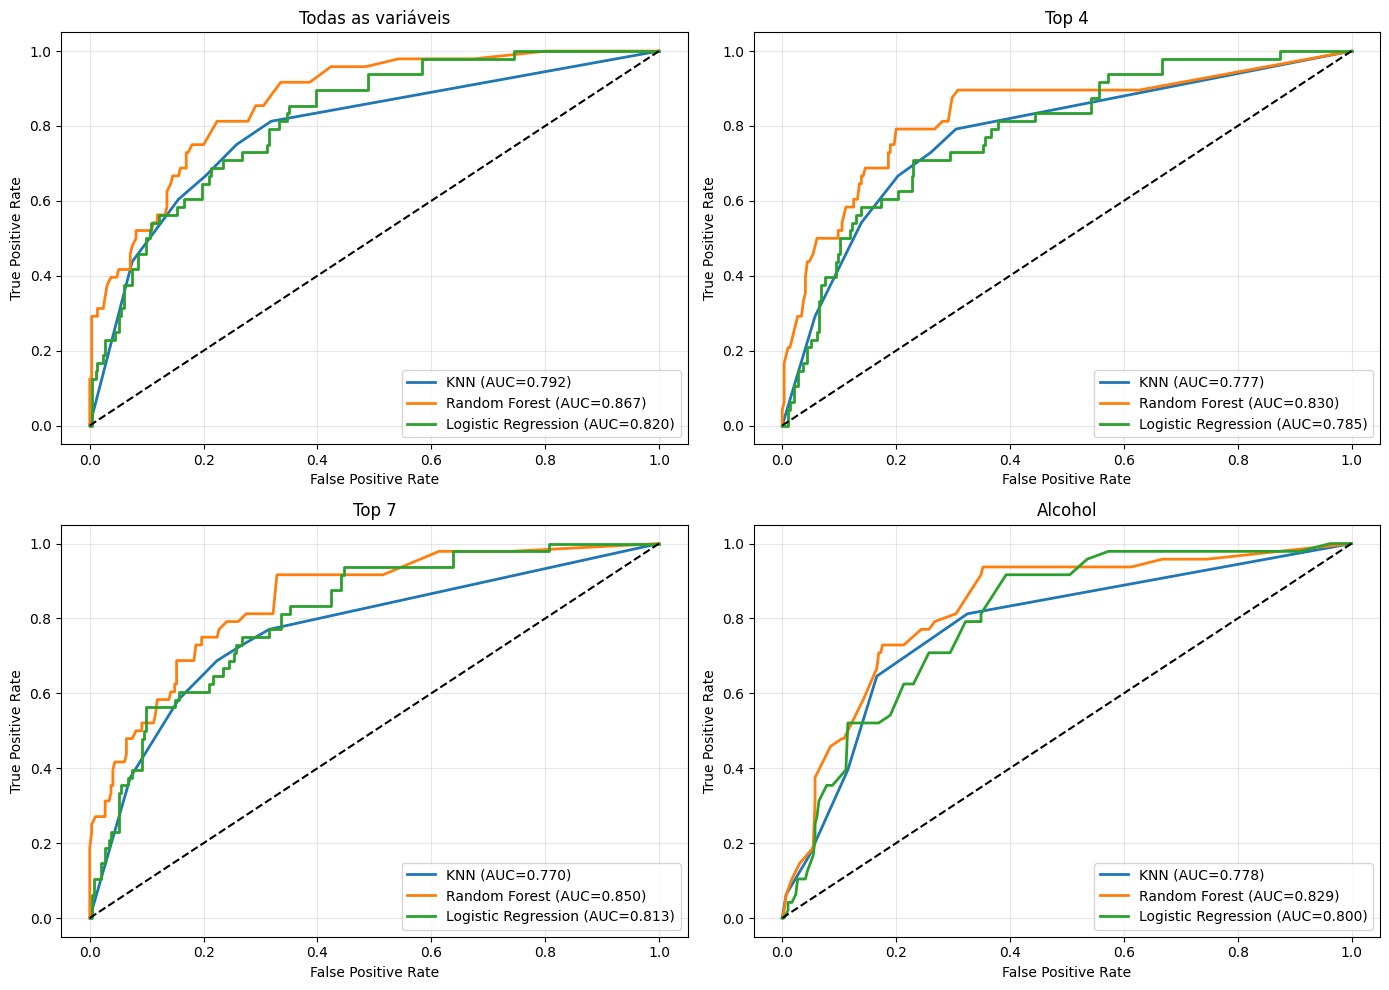

In [132]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilidades Logistic Regression
y_prob_log_all = log_reg_all.predict_proba(X_test_scaled_all)[:,1]
y_prob_log_top4 = log_reg_top4.predict_proba(X_test_scaled_top4)[:,1]
y_prob_log_top7 = log_reg_top7.predict_proba(X_test_scaled_top7)[:,1]
y_prob_log_alcohol = log_reg_alcohol.predict_proba(X_test_scaled_alcohol)[:,1]

# Lista com os grupos (agora com 3 modelos)
dados = [
    ("Todas as variáveis", y_test_all, y_prob_knn_all, y_prob_rf_all, y_prob_log_all),
    ("Top 4", y_test_top4, y_prob_knn_top4, y_prob_rf_top4, y_prob_log_top4),
    ("Top 7", y_test_top7, y_prob_knn_top7, y_prob_rf_top7, y_prob_log_top7),
    ("Alcohol", y_test_alcohol, y_prob_knn_alcohol, y_prob_rf_alcohol, y_prob_log_alcohol)
]

# Figura
fig, axs = plt.subplots(2, 2, figsize=(14,10))
axs = axs.ravel()

for ax, (titulo, y_true, prob_knn, prob_rf, prob_log) in zip(axs, dados):

    # KNN
    fpr_knn, tpr_knn, _ = roc_curve(y_true, prob_knn)
    auc_knn = roc_auc_score(y_true, prob_knn)

    # Random Forest
    fpr_rf, tpr_rf, _ = roc_curve(y_true, prob_rf)
    auc_rf = roc_auc_score(y_true, prob_rf)

    # Logistic Regression
    fpr_log, tpr_log, _ = roc_curve(y_true, prob_log)
    auc_log = roc_auc_score(y_true, prob_log)

    # Plotar curvas
    ax.plot(fpr_knn, tpr_knn, linewidth=2, label=f'KNN (AUC={auc_knn:.3f})')
    ax.plot(fpr_rf, tpr_rf, linewidth=2, label=f'Random Forest (AUC={auc_rf:.3f})')
    ax.plot(fpr_log, tpr_log, linewidth=2, label=f'Logistic Regression (AUC={auc_log:.3f})')

    # Linha diagonal
    ax.plot([0,1],[0,1],'k--')

    ax.set_title(titulo)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()

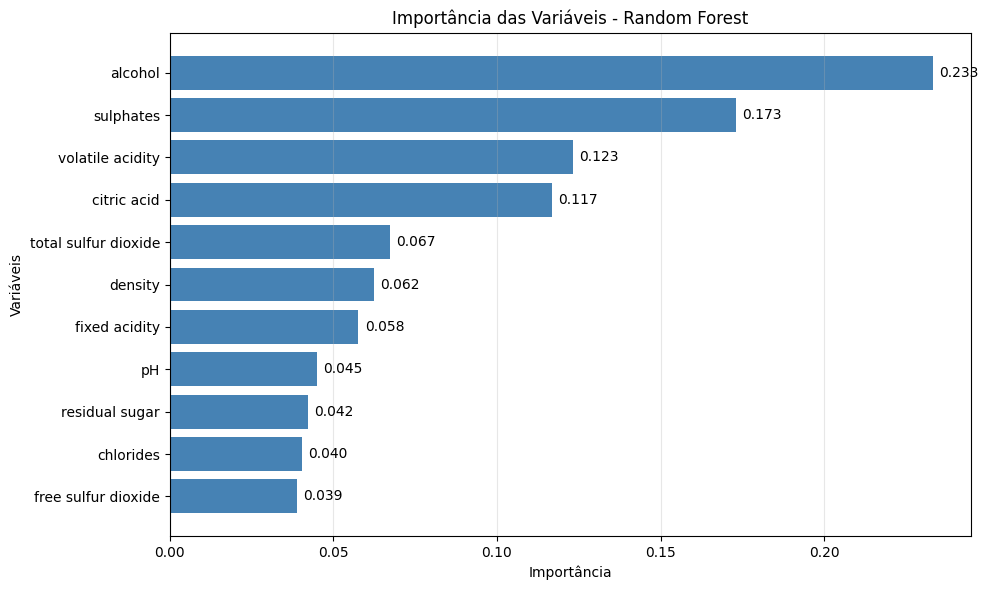

In [137]:
import pandas as pd
import matplotlib.pyplot as plt

# Importância das variáveis
importancias = rf_all.feature_importances_

# DataFrame
df_importancia = pd.DataFrame({
    'Variável': features_all,
    'Importância': importancias
}).sort_values(by='Importância', ascending=False)

# Gráfico
plt.figure(figsize=(10,6))
plt.barh(df_importancia['Variável'], df_importancia['Importância'], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Importância')
plt.ylabel('Variáveis')
plt.title('Importância das Variáveis - Random Forest')
plt.grid(axis='x', alpha=0.3)

# Valores nas barras
for i, v in enumerate(df_importancia['Importância']):
    plt.text(v + 0.002, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()